<div style="background: linear-gradient(90deg, #1b5e20 0%, #2e7d32 100%); border-radius: 10px; padding: 18px 28px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.2);">
    <h1 style="margin: 0; color: white; font-size: 26px; font-weight: 700; text-shadow: 1px 1px 2px rgba(0,0,0,0.3);">🌲 Swin Transformer — RealWaste Classifier</h1>
    <p style="margin: 8px 0 0 0; color: #c8e6c9; font-size: 14px;">Swin-B backbone · Shifted-window attention · 2-stage fine-tuning · Full evaluation pipeline</p>
</div>

<div style="background: linear-gradient(90deg, #1b5e20 0%, #2e7d32 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700;">📦 1. Install Dependencies</h2>
</div>

### Why Swin Transformer over PVT-v2-B3?

| Model | Params | ImageNet Top-1 | Key advantage |
|---|---|---|---|
| `pvt_v2_b3` | ~45 M | ~83.2% | Linear attention, dense tasks |
| `swin_small_patch4_window7_224` | ~50 M | ~83.2% | Shifted windows, strong locality |
| `swin_base_patch4_window7_224` | ~88 M | **~85.2%** | Larger capacity, better generalisation |
| `swin_base_patch4_window12_384` | ~88 M | **~86.4%** | Higher-resolution variant |

Swin Transformer uses **hierarchical shifted-window self-attention**, which captures both local texture (important for garbage materials like plastic, glass) and global context — a strong fit for the RealWaste dataset.

In [3]:
!pip install -q torch torchvision scikit-learn seaborn tqdm
!pip install -q timm==0.9.2  # Swin models are available in timm

<div style="background: linear-gradient(90deg, #1b5e20 0%, #2e7d32 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700;">📚 2. Imports &amp; Seed</h2>
</div>

In [4]:
import os
import copy
import json
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms

import timm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('PyTorch:', torch.__version__)
print('timm:', timm.__version__)

Device: cuda
PyTorch: 2.10.0+cu128
timm: 0.9.2


<div style="background: linear-gradient(90deg, #1b5e20 0%, #2e7d32 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700;">📂 3. Locate Dataset Automatically</h2>
</div>

In [5]:
candidate_paths = [
    Path('/kaggle/input/datasets/joebeachcapital/realwaste/realwaste-main/RealWaste'),
    # Add alternate paths here if needed:
    # Path('/kaggle/input/realwaste/RealWaste'),
]

def is_dataset_root(path: Path) -> bool:
    if not path.exists() or not path.is_dir():
        return False
    class_dirs = [p for p in path.iterdir() if p.is_dir()]
    if len(class_dirs) < 2:
        return False
    has_images = any(
        any(c.glob('*.jpg')) or any(c.glob('*.jpeg')) or any(c.glob('*.png'))
        for c in class_dirs
    )
    return has_images

data_dir = None
for p in candidate_paths:
    if is_dataset_root(p):
        data_dir = p
        break

if data_dir is None:
    raise FileNotFoundError('No valid dataset root found. Update candidate_paths manually.')

print('Using dataset path:', data_dir)

Using dataset path: /kaggle/input/datasets/joebeachcapital/realwaste/realwaste-main/RealWaste


<div style="background: linear-gradient(90deg, #1b5e20 0%, #2e7d32 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700;">📊 4. Build File Index and Inspect Class Balance</h2>
</div>

Total images: 4752
Classes: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']


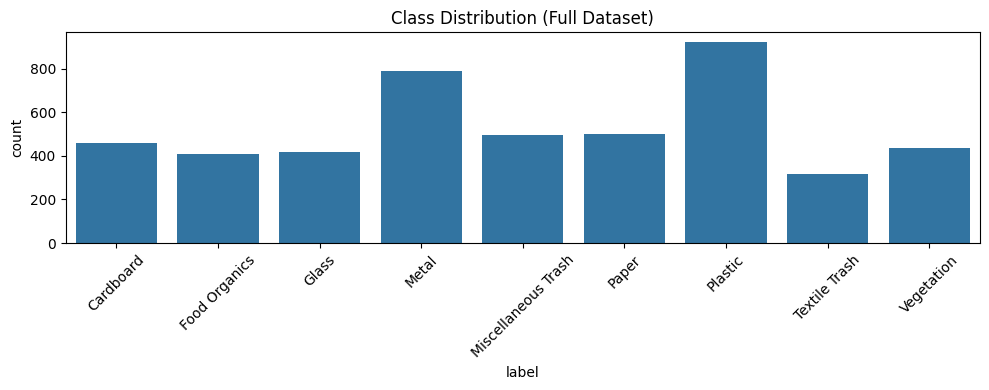

In [6]:
valid_ext = {'.jpg', '.jpeg', '.png'}
records = []

class_names = sorted([p.name for p in data_dir.iterdir() if p.is_dir()])
class_to_idx = {c: i for i, c in enumerate(class_names)}

for cls in class_names:
    cls_dir = data_dir / cls
    for img_path in cls_dir.rglob('*'):
        if img_path.suffix.lower() in valid_ext:
            records.append({
                'filepath': str(img_path),
                'label': cls,
                'label_idx': class_to_idx[cls]
            })

df = pd.DataFrame(records)
print('Total images:', len(df))
print('Classes:', class_names)

plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='label', order=class_names)
plt.xticks(rotation=45)
plt.title('Class Distribution (Full Dataset)')
plt.tight_layout()
plt.show()

<div style="background: linear-gradient(90deg, #1b5e20 0%, #2e7d32 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700;">⚙️ 5. Stratified Train / Validation / Test Split</h2>
</div>

In [7]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df['label_idx'],
    random_state=SEED,
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label_idx'],
    random_state=SEED,
)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

for name, split in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    counts = split['label'].value_counts().sort_index()
    print(f'\n{name} split class counts:')
    print(counts.to_string())

Train: 3801 | Val: 475 | Test: 476

Train split class counts:
label
Cardboard              369
Food Organics          329
Glass                  336
Metal                  632
Miscellaneous Trash    396
Paper                  400
Plastic                736
Textile Trash          254
Vegetation             349

Val split class counts:
label
Cardboard              46
Food Organics          41
Glass                  42
Metal                  79
Miscellaneous Trash    49
Paper                  50
Plastic                92
Textile Trash          32
Vegetation             44

Test split class counts:
label
Cardboard              46
Food Organics          41
Glass                  42
Metal                  79
Miscellaneous Trash    50
Paper                  50
Plastic                93
Textile Trash          32
Vegetation             43


<div style="background: linear-gradient(90deg, #1b5e20 0%, #2e7d32 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700;">🧪 6. Dataset Class and Transforms</h2>
</div>

**Swin-specific note:** Swin Transformer uses `224×224` by default. The `swin_base_patch4_window12_384` variant expects `384×384` — update `IMG_SIZE` and `BACKBONE` together if switching to the 384 model. We also add **RandAugment** for stronger regularisation, which helps the larger Swin-B model avoid overfitting on RealWaste.

In [8]:
# ── Config ──────────────────────────────────────────────────────────────────
# Swin variants available in timm:
#   swin_tiny_patch4_window7_224   (~28 M)  fast, good baseline
#   swin_small_patch4_window7_224  (~50 M)  balanced
#   swin_base_patch4_window7_224   (~88 M)  recommended ✅  (used below)
#   swin_base_patch4_window12_384  (~88 M)  higher-res, set IMG_SIZE=384
#   swin_large_patch4_window7_224  (~197 M) needs >16 GB VRAM

BACKBONE   = 'swin_base_patch4_window7_224'
IMG_SIZE   = 224   # change to 384 if using window12_384 variant
BATCH_SIZE = 32
NUM_WORKERS = 2

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── Transforms ──────────────────────────────────────────────────────────────
# RandAugment + RandomErasing give Swin-B meaningful regularisation boosts.
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),  # slight over-size then crop
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.05),
    transforms.RandAugment(num_ops=2, magnitude=9),   # ← stronger augmentation
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15)),  # ← random erasing
])

val_test_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class GarbageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['filepath']).convert('RGB')
        label = int(row['label_idx'])
        if self.transform:
            image = self.transform(image)
        return image, label


train_ds = GarbageDataset(train_df, transform=train_tfms)
val_ds   = GarbageDataset(val_df,   transform=val_test_tfms)
test_ds  = GarbageDataset(test_df,  transform=val_test_tfms)

print('Datasets ready.')

Datasets ready.


<div style="background: linear-gradient(90deg, #1b5e20 0%, #2e7d32 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700;">⚖️ 7. DataLoaders with Class-Imbalance Handling</h2>
</div>

In [9]:
train_labels = train_df['label_idx'].values
class_sample_count = np.array([np.sum(train_labels == t) for t in range(len(class_names))])
class_weights = 1.0 / np.maximum(class_sample_count, 1)
sample_weights = class_weights[train_labels]

sampler = WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights).double(),
    num_samples=len(sample_weights),
    replacement=True,
)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, sampler=sampler,
    num_workers=NUM_WORKERS, pin_memory=True,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
)

print('Loaders ready:', len(train_loader), len(val_loader), len(test_loader))

Loaders ready: 119 15 15


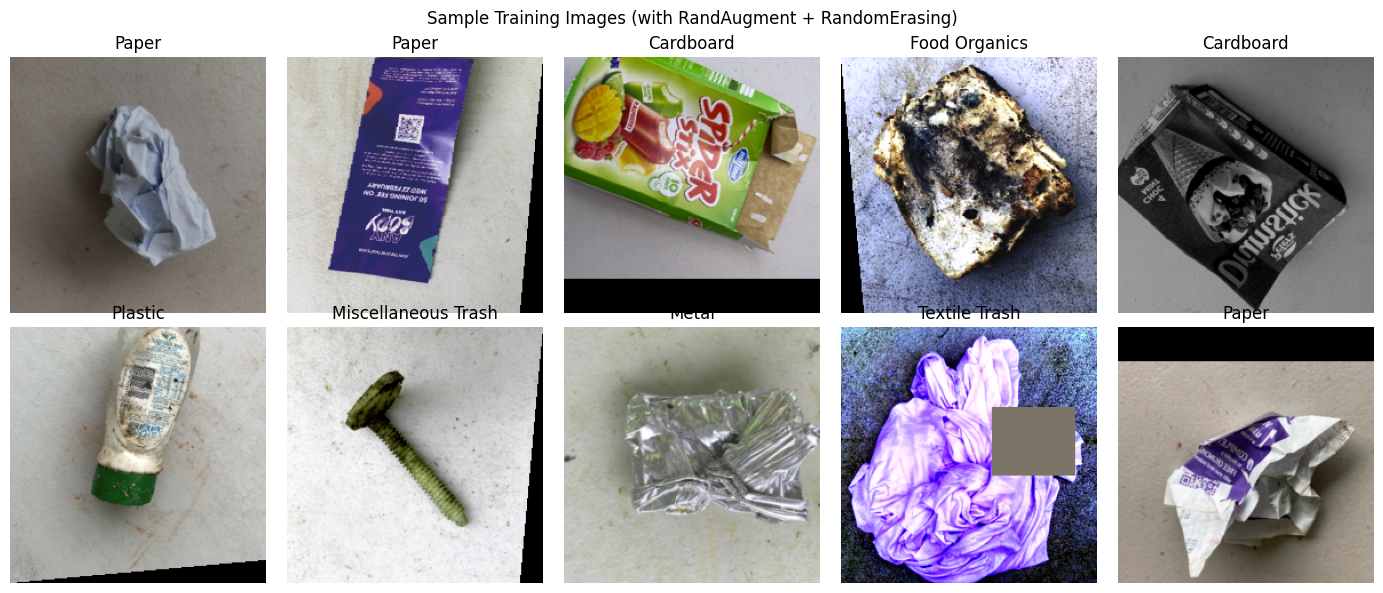

In [10]:
def denormalize(img_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    mean = torch.tensor(mean).view(3, 1, 1)
    std  = torch.tensor(std).view(3, 1, 1)
    return (img_tensor * std + mean).clamp(0, 1)

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flatten()):
    img = denormalize(images[i].cpu())
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(class_names[labels[i].item()])
    ax.axis('off')
plt.suptitle('Sample Training Images (with RandAugment + RandomErasing)')
plt.tight_layout()
plt.show()

<div style="background: linear-gradient(90deg, #1b5e20 0%, #2e7d32 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700;">🌲 8. Build Swin Transformer Model</h2>
</div>

Swin Transformer uses **shifted-window self-attention** across 4 hierarchical stages, similar to how CNNs build from edges → textures → objects. This hierarchical design gives Swin strong locality bias — beneficial for distinguishing visually similar waste categories (e.g. plastic vs. glass).

In timm, Swin's classification head is `model.head` (a single `nn.Linear`). We freeze the backbone and only train the head in Stage 1.

In [11]:
def build_swin_model(
    backbone: str = 'swin_base_patch4_window7_224',
    num_classes: int = 10,
    freeze_features: bool = True,
    pretrained: bool = True,
):
    """
    Build a Swin Transformer model for image classification.

    Args:
        backbone        : timm model name, e.g. 'swin_base_patch4_window7_224'
        num_classes     : number of output classes
        freeze_features : if True, freeze all layers except the classification head
        pretrained      : load ImageNet-22k or ImageNet-1k pre-trained weights

    Returns:
        model (nn.Module)
    """
    model = timm.create_model(
        backbone,
        pretrained=pretrained,
        num_classes=num_classes,
    )

    if freeze_features:
        # Freeze everything first
        for p in model.parameters():
            p.requires_grad = False

        # Swin in timm exposes the head as model.head
        head = getattr(model, 'head', None)
        if head is None:
            head = getattr(model, 'classifier', None)
        if head is not None:
            for p in head.parameters():
                p.requires_grad = True
        else:
            # fallback: unfreeze last Linear
            for m in reversed(list(model.modules())):
                if isinstance(m, nn.Linear):
                    for p in m.parameters():
                        p.requires_grad = True
                    break

        # Also unfreeze norm layer (layer-norm before head) for better convergence
        norm = getattr(model, 'norm', None)
        if norm is not None:
            for p in norm.parameters():
                p.requires_grad = True

    return model


model = build_swin_model(
    backbone=BACKBONE,
    num_classes=len(class_names),
    freeze_features=True,
    pretrained=True,
).to(device)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
all_params       = sum(p.numel() for p in model.parameters())
print(f'Backbone        : {BACKBONE}')
print(f'Trainable params: {trainable_params:,} / {all_params:,}')
print(f'Frozen params   : {all_params - trainable_params:,}')
print(f'Model head      : {model.head}')

/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Backbone        : swin_base_patch4_window7_224
Trainable params: 11,273 / 86,752,449
Frozen params   : 86,741,176
Model head      : ClassifierHead(
  (global_pool): SelectAdaptivePool2d (pool_type=avg, flatten=Identity())
  (drop): Dropout(p=0.0, inplace=False)
  (fc): Linear(in_features=1024, out_features=9, bias=True)
  (flatten): Identity()
)


<div style="background: linear-gradient(90deg, #1b5e20 0%, #2e7d32 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700;">🛠️ 9. Training Utilities</h2>
</div>

Two improvements over the PVT notebook:
1. **Label smoothing** (`CrossEntropyLoss(label_smoothing=0.1)`) — reduces overconfidence, especially helpful with Swin-B's higher capacity.
2. **Cosine annealing** scheduler — smoother LR decay than `ReduceLROnPlateau`, commonly used in Swin training.

In [12]:
def accuracy_from_logits(logits, targets):
    preds = logits.argmax(dim=1)
    return (preds == targets).float().mean().item()


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    losses, accs = [], []
    for images, targets in loader:
        images, targets = images.to(device), targets.to(device)
        logits = model(images)
        if hasattr(logits, 'logits'):
            logits = logits.logits
        loss = criterion(logits, targets)
        losses.append(loss.item())
        accs.append(accuracy_from_logits(logits, targets))
    return float(np.mean(losses)), float(np.mean(accs))


def train_one_epoch(model, loader, criterion, optimizer, scaler=None):
    model.train()
    losses, accs = [], []
    for images, targets in tqdm(loader, leave=False, desc='train'):
        images, targets = images.to(device), targets.to(device)
        optimizer.zero_grad()

        if scaler is not None:  # AMP mixed precision
            with torch.cuda.amp.autocast():
                logits = model(images)
                if hasattr(logits, 'logits'):
                    logits = logits.logits
                loss = criterion(logits, targets)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(images)
            if hasattr(logits, 'logits'):
                logits = logits.logits
            loss = criterion(logits, targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

        losses.append(loss.item())
        accs.append(accuracy_from_logits(logits, targets))
    return float(np.mean(losses)), float(np.mean(accs))


def fit(
    model,
    train_loader,
    val_loader,
    epochs=12,
    lr=1e-3,
    weight_decay=1e-4,
    patience=4,
    label_smoothing=0.1,
    use_cosine=True,
    use_amp=True,
):
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=weight_decay,
    )

    if use_cosine:
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=epochs, eta_min=lr * 0.01
        )
    else:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.3, patience=2
        )

    # AMP scaler (only meaningful on CUDA)
    scaler = torch.cuda.amp.GradScaler() if (use_amp and device.type == 'cuda') else None

    history = []
    best_state    = copy.deepcopy(model.state_dict())
    best_val_loss = float('inf')
    no_improve    = 0

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
        val_loss,   val_acc   = evaluate(model, val_loader, criterion)

        if use_cosine:
            scheduler.step()
        else:
            scheduler.step(val_loss)

        row = {
            'epoch':      epoch,
            'lr':         optimizer.param_groups[0]['lr'],
            'train_loss': train_loss,
            'train_acc':  train_acc,
            'val_loss':   val_loss,
            'val_acc':    val_acc,
        }
        history.append(row)
        print(
            f"Epoch {epoch:02d}/{epochs} | lr {row['lr']:.2e} | "
            f"train_loss {train_loss:.4f} | train_acc {train_acc:.4f} | "
            f"val_loss {val_loss:.4f} | val_acc {val_acc:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = copy.deepcopy(model.state_dict())
            no_improve    = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print('Early stopping triggered.')
                break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)

<div style="background: linear-gradient(90deg, #1b5e20 0%, #2e7d32 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700;">🚀 10. Train — Stage 1 (Head + Norm Only)</h2>
</div>

Stage 1 trains only the classification head (and final LayerNorm) with the Swin backbone fully frozen. This acts as a warm-up, giving the head a sensible initialisation before full fine-tuning.

In [13]:
EPOCHS_S1 = 10
LR_S1     = 1e-3

model, history_stage1 = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS_S1,
    lr=LR_S1,
    weight_decay=1e-4,
    patience=4,
    label_smoothing=0.1,
    use_cosine=True,
    use_amp=True,
)

history_stage1.tail()

/tmp/ipykernel_55/2240170926.py:82: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if (use_amp and device.type == 'cuda') else None


train:   0%|          | 0/119 [00:00<?, ?it/s]

/tmp/ipykernel_55/2240170926.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 01/10 | lr 9.76e-04 | train_loss 1.2031 | train_acc 0.7108 | val_loss 0.8470 | val_acc 0.8555


train:   0%|          | 0/119 [00:00<?, ?it/s]

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ff1637a2980>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
         ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x7ff1637a2980>AssertionError
: can only test a child processTraceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
Exception ignored in:   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data

Epoch 09/10 | lr 3.42e-05 | train_loss 0.7532 | train_acc 0.9168 | val_loss 0.7276 | val_acc 0.9079


train:   0%|          | 0/119 [00:00<?, ?it/s]

Epoch 10/10 | lr 1.00e-05 | train_loss 0.7589 | train_acc 0.9135 | val_loss 0.7279 | val_acc 0.9100


,epoch,lr,train_loss,train_acc,val_loss,val_acc
5,6,0.000352,0.779631,0.896124,0.732887,0.912500
6,7,0.000214,0.783571,0.892784,0.728083,0.916667
7,8,0.000105,0.765100,0.909706,0.727727,0.914583
8,9,0.000034,0.753204,0.916796,0.727603,0.907948
9,10,0.000010,0.758877,0.913456,0.727939,0.910031


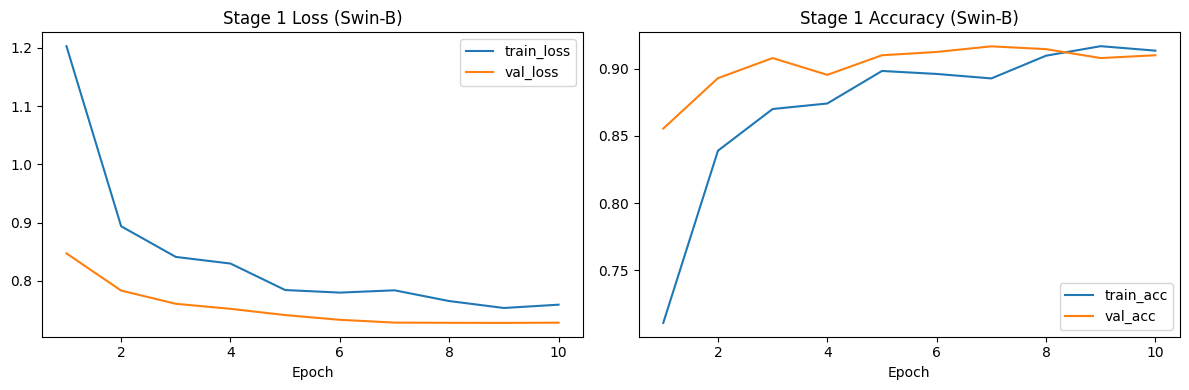

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_stage1['epoch'], history_stage1['train_loss'], label='train_loss')
axes[0].plot(history_stage1['epoch'], history_stage1['val_loss'],   label='val_loss')
axes[0].set_title('Stage 1 Loss (Swin-B)')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_stage1['epoch'], history_stage1['train_acc'], label='train_acc')
axes[1].plot(history_stage1['epoch'], history_stage1['val_acc'],   label='val_acc')
axes[1].set_title('Stage 1 Accuracy (Swin-B)')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

<div style="background: linear-gradient(90deg, #1b5e20 0%, #2e7d32 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700;">🎯 11. Fine-Tuning — Stage 2 (Gradual Unfreeze)</h2>
</div>

We use **layer-wise learning rate decay (LLRD)** — deeper (earlier) Swin layers get a smaller LR, since their ImageNet features are already well-trained. This prevents catastrophic forgetting and is the standard approach for Swin fine-tuning.

| Layer group | LR decay factor | Effective LR |
|---|---|---|
| Head + Norm | 1.0× | `1e-4` |
| Stage 4 (last) | 0.9× | `9e-5` |
| Stage 3 | 0.81× | `~8.1e-5` |
| Stage 2 | 0.73× | `~7.3e-5` |
| Stage 1 + patch embed | 0.66× | `~6.6e-5` |

In [15]:
def get_swin_param_groups(model, base_lr=1e-4, lr_decay=0.9):
    """
    Build parameter groups with layer-wise LR decay for Swin Transformer.
    Swin stages: patch_embed → layers.0 → layers.1 → layers.2 → layers.3 → norm → head
    """
    # Unfreeze all first
    for p in model.parameters():
        p.requires_grad = True

    depth_map = {
        'head':        base_lr,
        'norm':        base_lr,
        'layers.3':    base_lr * (lr_decay ** 1),
        'layers.2':    base_lr * (lr_decay ** 2),
        'layers.1':    base_lr * (lr_decay ** 3),
        'layers.0':    base_lr * (lr_decay ** 4),
        'patch_embed': base_lr * (lr_decay ** 5),
    }

    groups = []
    assigned = set()
    for prefix, lr in depth_map.items():
        params = [
            p for n, p in model.named_parameters()
            if n.startswith(prefix) and id(p) not in assigned
        ]
        for n, p in model.named_parameters():
            if n.startswith(prefix):
                assigned.add(id(p))
        if params:
            groups.append({'params': params, 'lr': lr})
            print(f'  {prefix}: {len(params)} tensors @ lr={lr:.2e}')

    # Any remaining params (shouldn't be many)
    remaining = [p for n, p in model.named_parameters() if id(p) not in assigned]
    if remaining:
        groups.append({'params': remaining, 'lr': base_lr * (lr_decay ** 5)})
        print(f'  other: {len(remaining)} tensors @ lr={base_lr * lr_decay**5:.2e}')

    return groups


print('Building LLRD param groups:')
param_groups = get_swin_param_groups(model, base_lr=1e-4, lr_decay=0.9)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nAll {trainable:,} parameters now trainable.')

Building LLRD param groups:
  head: 2 tensors @ lr=1.00e-04
  norm: 2 tensors @ lr=1.00e-04
  layers.3: 29 tensors @ lr=9.00e-05
  layers.2: 237 tensors @ lr=8.10e-05
  layers.1: 29 tensors @ lr=7.29e-05
  layers.0: 26 tensors @ lr=6.56e-05
  patch_embed: 4 tensors @ lr=5.90e-05

All 86,752,449 parameters now trainable.


/tmp/ipykernel_55/2934248118.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler2 = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None


train:   0%|          | 0/119 [00:00<?, ?it/s]

/tmp/ipykernel_55/2240170926.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


S2 Epoch 01/8 | lr 9.62e-05 | train_loss 0.7732 | train_acc 0.8963 | val_loss 0.6930 | val_acc 0.9242


train:   0%|          | 0/119 [00:00<?, ?it/s]

...

S2 Epoch 06/8 | lr 1.55e-05 | train_loss 0.5195 | train_acc 0.9945 | val_loss 0.6074 | val_acc 0.9559


train:   0%|          | 0/119 [00:00<?, ?it/s]

S2 Epoch 07/8 | lr 4.77e-06 | train_loss 0.5171 | train_acc 0.9940 | val_loss 0.5913 | val_acc 0.9604


train:   0%|          | 0/119 [00:00<?, ?it/s]

S2 Epoch 08/8 | lr 1.00e-06 | train_loss 0.5166 | train_acc 0.9953 | val_loss 0.5907 | val_acc 0.9621


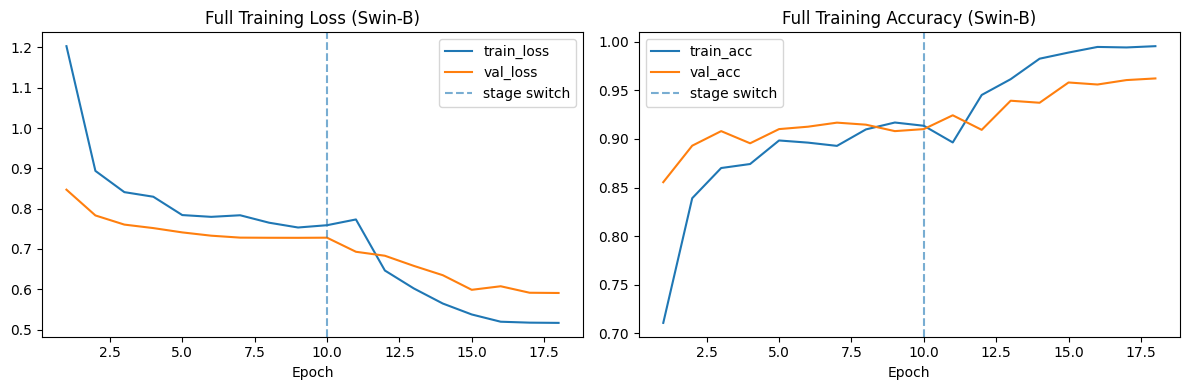

In [16]:
# ── Stage 2: Full fine-tuning with LLRD ──────────────────────────────────────
criterion  = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer2 = torch.optim.AdamW(param_groups, weight_decay=1e-5)
scheduler2 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer2, T_max=8, eta_min=1e-6
)
scaler2 = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None

EPOCHS_S2 = 8
patience  = 4

history2 = []
best_state    = copy.deepcopy(model.state_dict())
best_val_loss = float('inf')
no_improve    = 0

for epoch in range(1, EPOCHS_S2 + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer2, scaler2)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion)
    scheduler2.step()

    row = {
        'epoch':      epoch,
        'lr':         optimizer2.param_groups[0]['lr'],
        'train_loss': train_loss,
        'train_acc':  train_acc,
        'val_loss':   val_loss,
        'val_acc':    val_acc,
    }
    history2.append(row)
    print(
        f"S2 Epoch {epoch:02d}/{EPOCHS_S2} | lr {row['lr']:.2e} | "
        f"train_loss {train_loss:.4f} | train_acc {train_acc:.4f} | "
        f"val_loss {val_loss:.4f} | val_acc {val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state    = copy.deepcopy(model.state_dict())
        no_improve    = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print('Early stopping triggered.')
            break

model.load_state_dict(best_state)
history_stage2 = pd.DataFrame(history2)

# Merge both stages
h1 = history_stage1.copy()
h2 = history_stage2.copy()
if len(h2) > 0:
    h2['epoch'] = h2['epoch'] + h1['epoch'].max()
history_all = pd.concat([h1, h2], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_all['epoch'], history_all['train_loss'], label='train_loss')
axes[0].plot(history_all['epoch'], history_all['val_loss'],   label='val_loss')
axes[0].axvline(h1['epoch'].max(), linestyle='--', alpha=0.6, label='stage switch')
axes[0].set_title('Full Training Loss (Swin-B)')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_all['epoch'], history_all['train_acc'], label='train_acc')
axes[1].plot(history_all['epoch'], history_all['val_acc'],   label='val_acc')
axes[1].axvline(h1['epoch'].max(), linestyle='--', alpha=0.6, label='stage switch')
axes[1].set_title('Full Training Accuracy (Swin-B)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
plt.tight_layout()
plt.show()

<div style="background: linear-gradient(90deg, #1b5e20 0%, #2e7d32 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700;">📈 12. Test Set Evaluation</h2>
</div>

predicting:   0%|          | 0/15 [00:00<?, ?it/s]

Test Accuracy: 0.9622

Classification Report:
                     precision    recall  f1-score   support

          Cardboard     0.9773    0.9348    0.9556        46
      Food Organics     0.9524    0.9756    0.9639        41
              Glass     0.9767    1.0000    0.9882        42
              Metal     0.9750    0.9873    0.9811        79
Miscellaneous Trash     0.9792    0.9400    0.9592        50
              Paper     0.9423    0.9800    0.9608        50
            Plastic     0.9348    0.9247    0.9297        93
      Textile Trash     0.9677    0.9375    0.9524        32
         Vegetation     0.9773    1.0000    0.9885        43

           accuracy                         0.9622       476
          macro avg     0.9647    0.9644    0.9644       476
       weighted avg     0.9623    0.9622    0.9620       476



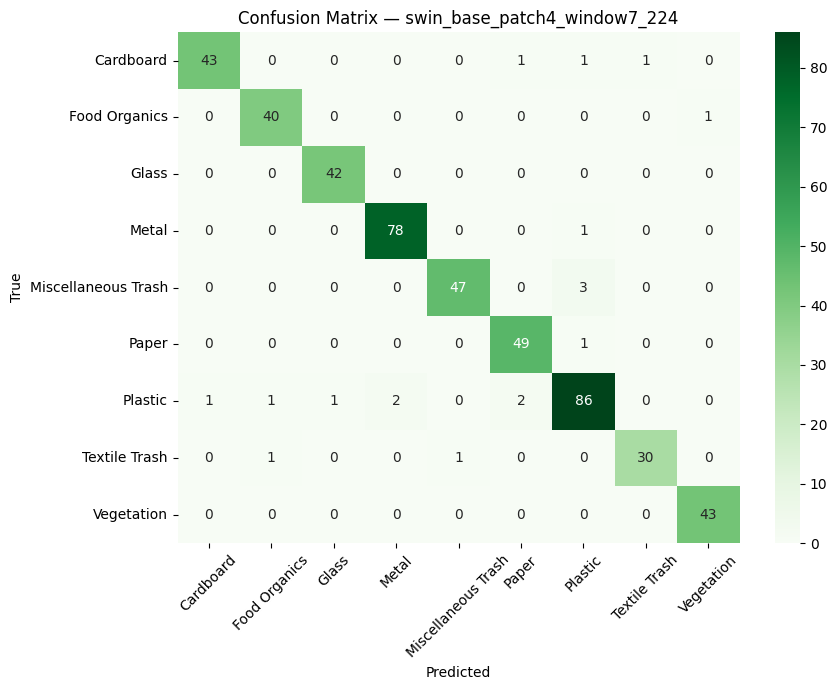

In [17]:
@torch.no_grad()
def predict_loader(model, loader):
    model.eval()
    all_preds, all_targets = [], []
    for images, targets in tqdm(loader, desc='predicting'):
        images = images.to(device)
        logits = model(images)
        if hasattr(logits, 'logits'):
            logits = logits.logits
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds.tolist())
        all_targets.extend(targets.numpy().tolist())
    return np.array(all_targets), np.array(all_preds)


y_true, y_pred = predict_loader(model, test_loader)

test_acc = (y_true == y_pred).mean()
print(f'Test Accuracy: {test_acc:.4f}')

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Greens',
    xticklabels=class_names, yticklabels=class_names
)
plt.title(f'Confusion Matrix — {BACKBONE}')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

<div style="background: linear-gradient(90deg, #1b5e20 0%, #2e7d32 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700;">📊 13. Detailed Metrics (Macro, Weighted, Per-Class)</h2>
</div>

In [18]:
overall_accuracy = accuracy_score(y_true, y_pred)
prec_macro,    rec_macro,    f1_macro,    _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro', zero_division=0
)
prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted', zero_division=0
)

print('=== Overall Metrics ===')
print(f'Accuracy      : {overall_accuracy:.4f}')
print(f'Precision(Ma) : {prec_macro:.4f}')
print(f'Recall(Ma)    : {rec_macro:.4f}')
print(f'F1-Score(Ma)  : {f1_macro:.4f}')
print(f'Precision(Wt) : {prec_weighted:.4f}')
print(f'Recall(Wt)    : {rec_weighted:.4f}')
print(f'F1-Score(Wt)  : {f1_weighted:.4f}')

p, r, f1, s = precision_recall_fscore_support(
    y_true, y_pred, labels=list(range(len(class_names))), zero_division=0
)

metrics_df = pd.DataFrame({
    'class':     class_names,
    'precision': p,
    'recall':    r,
    'f1_score':  f1,
    'support':   s,
}).sort_values('f1_score', ascending=False)

print('\n=== Per-Class Metrics (sorted by F1) ===')
display(metrics_df.style.format({
    'precision': '{:.4f}',
    'recall':    '{:.4f}',
    'f1_score':  '{:.4f}',
}))

=== Overall Metrics ===
Accuracy      : 0.9622
Precision(Ma) : 0.9647
Recall(Ma)    : 0.9644
F1-Score(Ma)  : 0.9644
Precision(Wt) : 0.9623
Recall(Wt)    : 0.9622
F1-Score(Wt)  : 0.9620

=== Per-Class Metrics (sorted by F1) ===


,class,precision,recall,f1_score,support
8,Vegetation,0.9773,1.0000,0.9885,43
2,Glass,0.9767,1.0000,0.9882,42
3,Metal,0.9750,0.9873,0.9811,79
1,Food Organics,0.9524,0.9756,0.9639,41
5,Paper,0.9423,0.9800,0.9608,50
4,Miscellaneous Trash,0.9792,0.9400,0.9592,50
0,Cardboard,0.9773,0.9348,0.9556,46
7,Textile Trash,0.9677,0.9375,0.9524,32
6,Plastic,0.9348,0.9247,0.9297,93


<div style="background: linear-gradient(90deg, #1b5e20 0%, #2e7d32 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700;">🔍 14. Low-F1 Class Diagnostic &amp; Recommendations</h2>
</div>

In [19]:
threshold_f1  = 0.93
fallback_top_n = 3

low_f1_df  = metrics_df.sort_values('f1_score', ascending=True).copy()
flagged_df = low_f1_df[low_f1_df['f1_score'] < threshold_f1].copy()

if flagged_df.empty:
    flagged_df = low_f1_df.head(fallback_top_n).copy()

suggestion_map = {
    'trash':      'Increase samples + hard augmentations (random crop, blur, brightness/contrast).',
    'plastic':    'Add look-alike negatives (glass/metal) and stronger color/texture augmentation.',
    'metal':      'Add edge/reflective examples; train with higher-resolution images.',
    'paper':      'Add crumpled/wet variants and background diversity.',
    'glass':      'Include transparent/reflective cases with varied lighting.',
    'battery':    'Add close-up and distance variants; balance orientation examples.',
    'cardboard':  'Add folded/torn variants and cluttered backgrounds.',
    'shoes':      'Use occlusion augmentation and mixed-background samples.',
    'biological': 'Include decomposition/shape diversity and lighting changes.',
    'clothes':    'Add texture and color diversity with background clutter.',
}

flagged_df['gap_to_0.95'] = (0.95 - flagged_df['f1_score']).clip(lower=0)
flagged_df['recommended_action'] = flagged_df['class'].map(suggestion_map).fillna(
    'Use class-focused augmentation + collect more hard samples for this class.'
)

print(f'=== Low-F1 Class Diagnostic (threshold: {threshold_f1:.2f}) ===')
print(f'Flagged classes: {len(flagged_df)}')
display(
    flagged_df[['class', 'precision', 'recall', 'f1_score', 'support', 'gap_to_0.95', 'recommended_action']]
    .style
    .format({
        'precision':   '{:.4f}',
        'recall':      '{:.4f}',
        'f1_score':    '{:.4f}',
        'gap_to_0.95': '{:.4f}',
    })
)

print('\nQuick priority order (most urgent first):')
for _, row in flagged_df.sort_values('f1_score').iterrows():
    print(f"  - {row['class']}: F1={row['f1_score']:.4f} | {row['recommended_action']}")

=== Low-F1 Class Diagnostic (threshold: 0.93) ===
Flagged classes: 1


,class,precision,recall,f1_score,support,gap_to_0.95,recommended_action
6,Plastic,0.9348,0.9247,0.9297,93,0.0203,Use class-focused augmentation + collect more hard samples for this class.



Quick priority order (most urgent first):
  - Plastic: F1=0.9297 | Use class-focused augmentation + collect more hard samples for this class.


<div style="background: linear-gradient(90deg, #1b5e20 0%, #2e7d32 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700;">🖼️ 15. Single-Image Inference Utility</h2>
</div>

In [20]:
@torch.no_grad()
def predict_image(image_path, model, transform, class_names, top_k=5):
    model.eval()
    img = Image.open(image_path).convert('RGB')
    x = transform(img).unsqueeze(0).to(device)
    logits = model(x)
    if hasattr(logits, 'logits'):
        logits = logits.logits
    probs    = torch.softmax(logits, dim=1).cpu().numpy().squeeze()
    pred_idx = int(np.argmax(probs))
    top_k_idx = np.argsort(probs)[::-1][:top_k]
    top_k_results = [(class_names[i], float(probs[i])) for i in top_k_idx]
    return class_names[pred_idx], float(probs[pred_idx]), top_k_results


# Example usage (uncomment and edit path):
# sample_path = test_df.iloc[0]['filepath']
# pred_class, confidence, top5 = predict_image(sample_path, model, val_test_tfms, class_names)
# print(f'Predicted: {pred_class} | Confidence: {confidence:.4f}')
# for cls, prob in top5:
#     print(f'  {cls}: {prob:.4f}')

<div style="background: linear-gradient(90deg, #1b5e20 0%, #2e7d32 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700;">💾 16. Save Artifacts</h2>
</div>

In [21]:
artifacts_dir = Path('./artifacts')
artifacts_dir.mkdir(parents=True, exist_ok=True)

model_path        = artifacts_dir / f'{BACKBONE}_realwaste_best.pt'
meta_path         = artifacts_dir / 'metadata.json'
class_names_path  = artifacts_dir / 'class_names.json'
frontend_cfg_path = artifacts_dir / 'frontend_config.json'

torch.save({
    'model_state_dict': model.state_dict(),
    'backbone':         BACKBONE,
    'class_names':      class_names,
    'img_size':         IMG_SIZE,
    'mean':             IMAGENET_MEAN,
    'std':              IMAGENET_STD,
}, model_path)

with open(meta_path, 'w') as f:
    json.dump({
        'backbone':      BACKBONE,
        'class_names':   class_names,
        'img_size':      IMG_SIZE,
        'mean':          IMAGENET_MEAN,
        'std':           IMAGENET_STD,
        'test_accuracy': float(test_acc),
        'f1_macro':      float(f1_macro),
    }, f, indent=2)

with open(class_names_path, 'w') as f:
    json.dump(class_names, f, indent=2)

with open(frontend_cfg_path, 'w') as f:
    json.dump({
        'input_type':          'image_file',
        'accepted_extensions': ['jpg', 'jpeg', 'png'],
        'output': {
            'predicted_class': 'string',
            'confidence':      'float',
            'top_k': [{'class_name': 'string', 'probability': 'float'}],
        },
        'normalization': {
            'mean':   IMAGENET_MEAN,
            'std':    IMAGENET_STD,
            'resize': [IMG_SIZE, IMG_SIZE],
        },
    }, f, indent=2)

print('Saved model      :', model_path)
print('Saved metadata   :', meta_path)
print('Saved class names:', class_names_path)
print('Saved frontend   :', frontend_cfg_path)

Saved model      : artifacts/swin_base_patch4_window7_224_realwaste_best.pt
Saved metadata   : artifacts/metadata.json
Saved class names: artifacts/class_names.json
Saved frontend   : artifacts/frontend_config.json


<div style="background: linear-gradient(90deg, #1a237e 0%, #283593 100%); border-radius: 10px; padding: 18px 28px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.2);">
    <h1 style="margin: 0; color: white; font-size: 26px; font-weight: 700; text-shadow: 1px 1px 2px rgba(0,0,0,0.3);">🧠 Part 2 — Knowledge Distillation: Swin-B → Swin-Tiny</h1>
    <p style="margin: 8px 0 0 0; color: #b3c6ff; font-size: 14px;">Response-based KD · Feature-level matching · Attention Transfer · Swin-Tiny student</p>
</div>

<div style="background: linear-gradient(90deg, #1a237e 0%, #283593 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700;">🔧 KD-1. Distillation Config</h2>
</div>

### What we're doing and why

| Component | Choice | Reason |
|---|---|---|
| **Student backbone** | `swin_tiny_patch4_window7_224` (~28 M) | Same family as teacher → compatible feature spaces, 3× smaller |
| **Response KD** | Soft-label KL divergence (T=4) | Transfers inter-class similarity (e.g. plastic≈glass) |
| **Feature KD** | MSE on last Swin stage output (`layers.3`) | Structural knowledge beyond logits |
| **Attention Transfer** | L2 on attention maps per stage | Spatial locality — key for waste texture discrimination |
| **Loss weights** | α=0.3 CE hard + 0.4 KL soft + 0.2 feat + 0.1 attn | Balanced; CE keeps ground-truth anchoring |
| **Label smoothing** | 0.05 (reduced from teacher's 0.1) | Soft labels already act as smoothing — avoid double-smoothing |
| **Training stages** | Stage-A: head warm-up (5 ep) → Stage-B: full LLRD (20 ep) | Mirrors teacher recipe |
| **Temperature** | T = 4 | Softens teacher distribution; reveals dark knowledge |


In [22]:
# ── Knowledge Distillation Config ───────────────────────────────────────────
STUDENT_BACKBONE = 'swin_tiny_patch4_window7_224'   # ~28 M params (3× smaller than Swin-B)

# Loss weights  (must sum to 1.0)
KD_ALPHA     = 0.30   # weight for hard-label CE loss
KD_BETA      = 0.40   # weight for soft-label KL divergence (response KD)
KD_GAMMA     = 0.20   # weight for feature-map MSE (feature KD)
KD_DELTA     = 0.10   # weight for attention-transfer loss

assert abs(KD_ALPHA + KD_BETA + KD_GAMMA + KD_DELTA - 1.0) < 1e-6, "Weights must sum to 1"

KD_TEMPERATURE   = 4.0    # softens teacher logits; higher → softer distribution
KD_LABEL_SMOOTH  = 0.05   # reduced vs teacher (0.1) to avoid double-smoothing

KD_EPOCHS_A  = 5          # Stage-A: student head warm-up (backbone frozen)
KD_EPOCHS_B  = 20         # Stage-B: full distillation with LLRD
KD_LR_A      = 1e-3       # head-only LR
KD_LR_B      = 1e-4       # base LR for LLRD fine-tuning
KD_LR_DECAY  = 0.9        # LLRD decay factor (same as teacher)
KD_PATIENCE  = 5          # early stopping patience

print("KD Config:")
print(f"  Student     : {STUDENT_BACKBONE}")
print(f"  α CE        : {KD_ALPHA}  |  β KL  : {KD_BETA}")
print(f"  γ Feature   : {KD_GAMMA}  |  δ Attn: {KD_DELTA}")
print(f"  Temperature : {KD_TEMPERATURE}")
print(f"  Epochs A/B  : {KD_EPOCHS_A} / {KD_EPOCHS_B}")


KD Config:
  Student     : swin_tiny_patch4_window7_224
  α CE        : 0.3  |  β KL  : 0.4
  γ Feature   : 0.2  |  δ Attn: 0.1
  Temperature : 4.0
  Epochs A/B  : 5 / 20


<div style="background: linear-gradient(90deg, #1a237e 0%, #283593 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700;">📥 KD-2. Load Trained Teacher & Freeze It</h2>
</div>

The teacher (`model`) is already in memory from training above.  
We just switch it to eval mode and freeze all parameters — it acts as a **static oracle** during distillation.  
Teacher inference runs inside `torch.no_grad()` at every batch, so no extra VRAM is consumed for gradients.


In [23]:
# ── Teacher: the Swin-B model already trained above ──────────────────────────
teacher = model   # already in memory
teacher.eval()
for p in teacher.parameters():
    p.requires_grad = False

teacher_params = sum(p.numel() for p in teacher.parameters())
print(f"Teacher : {BACKBONE}  |  {teacher_params/1e6:.1f} M params  |  frozen ✓")


Teacher : swin_base_patch4_window7_224  |  86.8 M params  |  frozen ✓


<div style="background: linear-gradient(90deg, #1a237e 0%, #283593 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700;">🪝 KD-3. Feature & Attention Extractor Wrappers</h2>
</div>

We use **forward hooks** to capture intermediate tensors from both teacher and student without modifying their source code.

For Swin Transformer in timm, the hierarchy is:
```
patch_embed → layers.0 → layers.1 → layers.2 → layers.3 → norm → head
```
Each `layers.X` outputs a feature map of shape `(B, H*W, C)`.  
We hook `layers.3` (the deepest stage) for **feature-level MSE**.  
We hook all four stages for **attention-transfer loss**.


In [24]:
class FeatureHook:
    """
    Registers a forward hook on a named submodule and stores
    its output tensor after each forward pass.
    """
    def __init__(self, module):
        self.feature = None
        self._hook = module.register_forward_hook(self._hook_fn)

    def _hook_fn(self, module, input, output):
        # Swin layers.X returns a tensor (B, H*W, C)
        if isinstance(output, (tuple, list)):
            self.feature = output[0]
        else:
            self.feature = output

    def remove(self):
        self._hook.remove()


def register_swin_hooks(model):
    """
    Register hooks on all 4 Swin stages and return a dict of FeatureHook objects.
    Keys: 'stage0', 'stage1', 'stage2', 'stage3'  (stage3 = deepest)
    """
    hooks = {}
    for i in range(4):
        layer = model.layers[i]
        hooks[f'stage{i}'] = FeatureHook(layer)
    return hooks


# ── Register hooks on both models ───────────────────────────────────────────
teacher_hooks = register_swin_hooks(teacher)
print("Teacher hooks registered on: layers.0 → layers.3")

# Student will be created in the next cell; hooks registered there.


Teacher hooks registered on: layers.0 → layers.3


<div style="background: linear-gradient(90deg, #1a237e 0%, #283593 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700;">🎓 KD-4. Build Student (Swin-Tiny)</h2>
</div>

The student is a **pretrained Swin-Tiny** (ImageNet-1k weights) with a replaced classification head.  
We start with Stage-A: freeze backbone, train head only (warm-up).  
This gives the student a sensible initialisation before full distillation.


In [25]:
student = build_swin_model(
    backbone=STUDENT_BACKBONE,
    num_classes=len(class_names),
    freeze_features=True,   # Stage-A: head only
    pretrained=True,
).to(device)

student_hooks = register_swin_hooks(student)
print("Student hooks registered on: layers.0 → layers.3")

s_params = sum(p.numel() for p in student.parameters())
s_train  = sum(p.numel() for p in student.parameters() if p.requires_grad)
print(f"\nStudent : {STUDENT_BACKBONE}")
print(f"  Total  : {s_params/1e6:.1f} M params")
print(f"  Train  : {s_train/1e6:.1f} M params (Stage-A head-only)")
print(f"  Frozen : {(s_params-s_train)/1e6:.1f} M params")
print(f"\nCompression ratio  : {teacher_params/s_params:.1f}×  fewer params")


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Student hooks registered on: layers.0 → layers.3

Student : swin_tiny_patch4_window7_224
  Total  : 27.5 M params
  Train  : 0.0 M params (Stage-A head-only)
  Frozen : 27.5 M params

Compression ratio  : 3.2×  fewer params


<div style="background: linear-gradient(90deg, #1a237e 0%, #283593 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700;">🔌 KD-5. Feature Adapter (Dimension Alignment)</h2>
</div>

Teacher `layers.3` outputs `(B, H*W, C_teacher)` where `C_teacher = 1024`.  
Student `layers.3` outputs `(B, H*W, C_student)` where `C_student = 768`.  
They differ, so we use a **learnable linear adapter** on the student side to project its features  
into the teacher's feature space before computing MSE. The adapter is lightweight (~786 K params).


In [26]:
# Swin-B stage3 output dim = 1024, Swin-Tiny stage3 output dim = 768
TEACHER_DIM = 1024
STUDENT_DIM = 768

class FeatureAdapter(nn.Module):
    """
    Projects student feature dim → teacher feature dim.
    A simple 2-layer MLP with GELU activation.
    Kept small: no bottleneck needed since dims are similar.
    """
    def __init__(self, in_dim: int, out_dim: int):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.GELU(),
            nn.Linear(out_dim, out_dim),
        )

    def forward(self, x):
        return self.proj(x)


feature_adapter = FeatureAdapter(STUDENT_DIM, TEACHER_DIM).to(device)

adapter_params = sum(p.numel() for p in feature_adapter.parameters())
print(f"Feature adapter: {STUDENT_DIM} → {TEACHER_DIM}  |  {adapter_params/1e6:.2f} M params")


Feature adapter: 768 → 1024  |  1.84 M params


<div style="background: linear-gradient(90deg, #1a237e 0%, #283593 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700;">⚖️ KD-6. Combined Distillation Loss</h2>
</div>

The distillation loss has four components:

| Term | Formula | What it teaches |
|---|---|---|
| **Hard CE** | `CE(student_logits, true_labels)` | Ground truth labels |
| **Soft KL** | `KL(softmax(s/T) ‖ softmax(t/T)) × T²` | Inter-class similarity from teacher's soft distribution |
| **Feature MSE** | `MSE(adapter(s_feat), t_feat)` | Deep structural representations from stage 3 |
| **Attention Transfer** | `Σ L2(norm(s_attn²), norm(t_attn²))` per stage | Spatial attention patterns across all 4 stages |

The `T²` scaling factor on KL loss is mathematically necessary — it corrects for the gradient magnitude reduction caused by temperature scaling.


In [27]:
class KnowledgeDistillationLoss(nn.Module):
    """
    Combined KD loss:
      L = α·CE + β·KL(soft) + γ·FeatureMSE + δ·AttentionTransfer
    """
    def __init__(
        self,
        alpha: float = KD_ALPHA,
        beta:  float = KD_BETA,
        gamma: float = KD_GAMMA,
        delta: float = KD_DELTA,
        temperature: float = KD_TEMPERATURE,
        label_smoothing: float = KD_LABEL_SMOOTH,
        num_classes: int = None,
    ):
        super().__init__()
        self.alpha = alpha
        self.beta  = beta
        self.gamma = gamma
        self.delta = delta
        self.T     = temperature
        self.ce    = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
        self.kl    = nn.KLDivLoss(reduction='batchmean')
        self.mse   = nn.MSELoss()

    def response_kd(self, s_logits, t_logits):
        """Soft-label KL divergence with temperature scaling."""
        s_soft = torch.log_softmax(s_logits / self.T, dim=1)
        t_soft = torch.softmax(t_logits  / self.T, dim=1)
        return self.kl(s_soft, t_soft) * (self.T ** 2)

    def feature_kd(self, s_feat, t_feat, adapter):
        """MSE between adapted student features and teacher features."""
        s_proj = adapter(s_feat)
        return self.mse(s_proj, t_feat.detach())

    @staticmethod
    def _attention_map(feat):
        """
        Compute spatial attention map from feature tensor (B, L, C).
        AT loss: normalise squared sum over channel dim.
        """
        # feat: (B, L, C) → attention: (B, L)
        attn = feat.pow(2).mean(dim=-1)             # (B, L)
        # L2-normalise each sample
        norm = attn.norm(p=2, dim=1, keepdim=True).clamp(min=1e-6)
        return attn / norm                           # (B, L)

    def attention_transfer(self, s_hooks, t_hooks):
        """
        Attention transfer across all 4 Swin stages.
        Handles spatial size mismatch via interpolation.
        """
        at_loss = torch.tensor(0.0, device=device)
        n_stages = 0
        for key in ['stage0', 'stage1', 'stage2', 'stage3']:
            s_f = s_hooks[key].feature   # (B, Ls, Cs)
            t_f = t_hooks[key].feature   # (B, Lt, Ct)
            if s_f is None or t_f is None:
                continue
            s_at = self._attention_map(s_f)   # (B, Ls)
            t_at = self._attention_map(t_f)   # (B, Lt)

            # Handle sequence-length mismatch between Swin-B and Swin-Tiny
            if s_at.shape != t_at.shape:
                # Reshape to 2-D spatial, interpolate, flatten back
                B = s_at.shape[0]
                Ls = s_at.shape[1]
                Lt = t_at.shape[1]
                H_s = W_s = int(Ls ** 0.5)
                H_t = W_t = int(Lt ** 0.5)
                s_2d = s_at.view(B, 1, H_s, W_s)
                t_2d = t_at.view(B, 1, H_t, W_t)
                # Upsample smaller to match larger
                if Ls < Lt:
                    s_2d = torch.nn.functional.interpolate(
                        s_2d, size=(H_t, W_t), mode='bilinear', align_corners=False
                    )
                else:
                    t_2d = torch.nn.functional.interpolate(
                        t_2d, size=(H_s, W_s), mode='bilinear', align_corners=False
                    )
                s_at = s_2d.view(B, -1)
                t_at = t_2d.view(B, -1)

            at_loss = at_loss + torch.nn.functional.mse_loss(s_at, t_at.detach())
            n_stages += 1

        return at_loss / max(n_stages, 1)

    def forward(
        self,
        s_logits, t_logits,
        targets,
        s_hooks=None, t_hooks=None,
        adapter=None,
    ):
        loss_ce   = self.ce(s_logits, targets)
        loss_kl   = self.response_kd(s_logits, t_logits)

        loss_feat = torch.tensor(0.0, device=device)
        if self.gamma > 0 and s_hooks and t_hooks and adapter:
            s_f = s_hooks['stage3'].feature
            t_f = t_hooks['stage3'].feature
            if s_f is not None and t_f is not None:
                loss_feat = self.feature_kd(s_f, t_f, adapter)

        loss_attn = torch.tensor(0.0, device=device)
        if self.delta > 0 and s_hooks and t_hooks:
            loss_attn = self.attention_transfer(s_hooks, t_hooks)

        total = (
            self.alpha * loss_ce
            + self.beta  * loss_kl
            + self.gamma * loss_feat
            + self.delta * loss_attn
        )
        return total, {
            'ce':   loss_ce.item(),
            'kl':   loss_kl.item(),
            'feat': loss_feat.item(),
            'attn': loss_attn.item(),
            'total': total.item(),
        }


kd_criterion = KnowledgeDistillationLoss(num_classes=len(class_names))
print("KD loss function ready.")
print(f"  α={KD_ALPHA} CE  |  β={KD_BETA} KL(T={KD_TEMPERATURE})  "
      f"|  γ={KD_GAMMA} Feat  |  δ={KD_DELTA} Attn")


KD loss function ready.
  α=0.3 CE  |  β=0.4 KL(T=4.0)  |  γ=0.2 Feat  |  δ=0.1 Attn


<div style="background: linear-gradient(90deg, #1a237e 0%, #283593 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700;">🔁 KD-7. Distillation Training Loop</h2>
</div>

**Important implementation details:**

1. Teacher runs in `eval()` + `torch.no_grad()` — same augmented batch as student (not clean images)  
2. Student hooks capture after the forward pass; teacher hooks capture during the teacher forward call  
3. AMP (`autocast`) wraps the full forward of both models + loss computation  
4. Gradient clipping at `max_norm=5.0` (same as teacher training)  
5. We track all four loss components separately for diagnostics


In [28]:
def kd_train_one_epoch(
    student, teacher,
    loader,
    kd_loss_fn,
    optimizer,
    adapter,
    student_hooks,
    teacher_hooks,
    scaler=None,
):
    student.train()
    teacher.eval()

    epoch_losses = {'ce': [], 'kl': [], 'feat': [], 'attn': [], 'total': []}
    accs = []

    for images, targets in tqdm(loader, leave=False, desc='kd-train'):
        images, targets = images.to(device), targets.to(device)
        optimizer.zero_grad()

        if scaler is not None:
            with torch.cuda.amp.autocast():
                # Teacher forward (no grad) — same augmented images
                with torch.no_grad():
                    t_logits = teacher(images)
                    if hasattr(t_logits, 'logits'):
                        t_logits = t_logits.logits

                # Student forward
                s_logits = student(images)
                if hasattr(s_logits, 'logits'):
                    s_logits = s_logits.logits

                total, components = kd_loss_fn(
                    s_logits, t_logits, targets,
                    s_hooks=student_hooks,
                    t_hooks=teacher_hooks,
                    adapter=adapter,
                )
            scaler.scale(total).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                list(student.parameters()) + list(adapter.parameters()), max_norm=5.0
            )
            scaler.step(optimizer)
            scaler.update()
        else:
            with torch.no_grad():
                t_logits = teacher(images)
                if hasattr(t_logits, 'logits'):
                    t_logits = t_logits.logits
            s_logits = student(images)
            if hasattr(s_logits, 'logits'):
                s_logits = s_logits.logits
            total, components = kd_loss_fn(
                s_logits, t_logits, targets,
                s_hooks=student_hooks,
                t_hooks=teacher_hooks,
                adapter=adapter,
            )
            total.backward()
            torch.nn.utils.clip_grad_norm_(
                list(student.parameters()) + list(adapter.parameters()), max_norm=5.0
            )
            optimizer.step()

        for k, v in components.items():
            epoch_losses[k].append(v)
        accs.append(accuracy_from_logits(s_logits, targets))

    return (
        {k: float(np.mean(v)) for k, v in epoch_losses.items()},
        float(np.mean(accs))
    )


@torch.no_grad()
def kd_evaluate(student, loader, criterion):
    """Standard evaluation using only hard CE (no teacher needed)."""
    return evaluate(student, loader, criterion)


print("KD training loop functions defined.")


KD training loop functions defined.


<div style="background: linear-gradient(90deg, #1a237e 0%, #283593 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700;">🚀 KD-8. Stage-A: Student Head Warm-Up</h2>
</div>

**Stage-A** (5 epochs): Only the student's classification head is trainable — backbone frozen.  
The adapter is also trained here. We use **only the soft-KL + CE terms** (α=0.5, β=0.5, γ=0, δ=0)  
because feature hooks from a cold backbone are noisy and unhelpful at this stage.


In [29]:
# Override γ and δ to zero for Stage-A warm-up
kd_criterion_warmup = KnowledgeDistillationLoss(
    alpha=0.5, beta=0.5, gamma=0.0, delta=0.0,
    temperature=KD_TEMPERATURE,
    label_smoothing=KD_LABEL_SMOOTH,
)

# Optimizer: student head + adapter only
stage_a_params = (
    list(filter(lambda p: p.requires_grad, student.parameters()))
    + list(feature_adapter.parameters())
)
optimizer_a = torch.optim.AdamW(stage_a_params, lr=KD_LR_A, weight_decay=1e-4)
scheduler_a = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_a, T_max=KD_EPOCHS_A, eta_min=KD_LR_A * 0.01
)
scaler_a = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None

# Hard CE for validation (no teacher)
hard_criterion = nn.CrossEntropyLoss()

history_kd_a = []
best_state_a    = copy.deepcopy(student.state_dict())
best_val_loss_a = float('inf')

print("=== Stage-A: Head Warm-Up ===")
for epoch in range(1, KD_EPOCHS_A + 1):
    losses, train_acc = kd_train_one_epoch(
        student, teacher, train_loader,
        kd_criterion_warmup, optimizer_a,
        feature_adapter, student_hooks, teacher_hooks,
        scaler=scaler_a,
    )
    val_loss, val_acc = kd_evaluate(student, val_loader, hard_criterion)
    scheduler_a.step()

    row = {
        'epoch': epoch, 'stage': 'A',
        'lr': optimizer_a.param_groups[0]['lr'],
        'train_acc': train_acc, 'val_loss': val_loss, 'val_acc': val_acc,
        **{f'loss_{k}': v for k, v in losses.items()}
    }
    history_kd_a.append(row)
    print(
        f"[A] Epoch {epoch:02d}/{KD_EPOCHS_A} | "
        f"lr {row['lr']:.2e} | total {losses['total']:.4f} "
        f"(ce {losses['ce']:.3f} kl {losses['kl']:.3f}) | "
        f"train_acc {train_acc:.4f} | val_acc {val_acc:.4f}"
    )

    if val_loss < best_val_loss_a:
        best_val_loss_a = val_loss
        best_state_a    = copy.deepcopy(student.state_dict())

student.load_state_dict(best_state_a)
history_kd_a = pd.DataFrame(history_kd_a)
print("\nStage-A complete. Best val loss:", round(best_val_loss_a, 4))


=== Stage-A: Head Warm-Up ===


/tmp/ipykernel_55/1509774705.py:17: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_a = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None


kd-train:   0%|          | 0/119 [00:00<?, ?it/s]

/tmp/ipykernel_55/1637053096.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


[A] Epoch 01/5 | lr 9.05e-04 | total 1.2051 (ce 1.283 kl 1.128) | train_acc 0.6454 | val_acc 0.7735


...

kd-train:   0%|          | 0/119 [00:00<?, ?it/s]

[A] Epoch 04/5 | lr 1.05e-04 | total 0.7866 (ce 0.828 kl 0.745) | train_acc 0.8138 | val_acc 0.8284


kd-train:   0%|          | 0/119 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ff1637a2980>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ff1637a2980>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

[A] Epoch 05/5 | lr 1.00e-05 | total 0.7940 (ce 0.828 kl 0.760) | train_acc 0.8047 | val_acc 0.8134

Stage-A complete. Best val loss: 0.5664


<div style="background: linear-gradient(90deg, #1a237e 0%, #283593 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700;">🎯 KD-9. Stage-B: Full Distillation with LLRD</h2>
</div>

**Stage-B** (up to 20 epochs): All student layers unfrozen. We apply the **full 4-component KD loss**  
and use **Layer-wise LR Decay** (same recipe as teacher Stage-2) to prevent catastrophic forgetting  
of ImageNet pretrained features in the shallow Swin-Tiny layers.


In [30]:
# ── Unfreeze student and build LLRD param groups ─────────────────────────────
print("Building LLRD param groups for student:")
student_param_groups = get_swin_param_groups(student, base_lr=KD_LR_B, lr_decay=KD_LR_DECAY)

# Add adapter params at the head LR
student_param_groups.append({
    'params': list(feature_adapter.parameters()),
    'lr': KD_LR_B,
})
print(f"  adapter: {len(list(feature_adapter.parameters()))} tensors @ lr={KD_LR_B:.2e}")

optimizer_b = torch.optim.AdamW(student_param_groups, weight_decay=1e-5)
scheduler_b = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_b, T_max=KD_EPOCHS_B, eta_min=1e-6
)
scaler_b = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None

history_kd_b = []
best_state_b    = copy.deepcopy(student.state_dict())
best_val_loss_b = float('inf')
no_improve_b    = 0

print("\n=== Stage-B: Full Distillation (Response + Feature + Attention) ===")
for epoch in range(1, KD_EPOCHS_B + 1):
    losses, train_acc = kd_train_one_epoch(
        student, teacher, train_loader,
        kd_criterion, optimizer_b,
        feature_adapter, student_hooks, teacher_hooks,
        scaler=scaler_b,
    )
    val_loss, val_acc = kd_evaluate(student, val_loader, hard_criterion)
    scheduler_b.step()

    row = {
        'epoch': epoch + KD_EPOCHS_A, 'stage': 'B',
        'lr': optimizer_b.param_groups[0]['lr'],
        'train_acc': train_acc, 'val_loss': val_loss, 'val_acc': val_acc,
        **{f'loss_{k}': v for k, v in losses.items()}
    }
    history_kd_b.append(row)
    print(
        f"[B] Epoch {epoch:02d}/{KD_EPOCHS_B} | "
        f"lr {row['lr']:.2e} | total {losses['total']:.4f} "
        f"(ce {losses['ce']:.3f} kl {losses['kl']:.3f} "
        f"feat {losses['feat']:.3f} attn {losses['attn']:.3f}) | "
        f"train_acc {train_acc:.4f} | val_acc {val_acc:.4f}"
    )

    if val_loss < best_val_loss_b:
        best_val_loss_b = val_loss
        best_state_b    = copy.deepcopy(student.state_dict())
        no_improve_b    = 0
    else:
        no_improve_b += 1
        if no_improve_b >= KD_PATIENCE:
            print("Early stopping triggered.")
            break

student.load_state_dict(best_state_b)
history_kd_b = pd.DataFrame(history_kd_b)
print("\nStage-B complete. Best val loss:", round(best_val_loss_b, 4))


Building LLRD param groups for student:
  head: 2 tensors @ lr=1.00e-04
  norm: 2 tensors @ lr=1.00e-04
  layers.3: 29 tensors @ lr=9.00e-05
  layers.2: 81 tensors @ lr=8.10e-05
  layers.1: 29 tensors @ lr=7.29e-05
  layers.0: 26 tensors @ lr=6.56e-05
  patch_embed: 4 tensors @ lr=5.90e-05
  adapter: 4 tensors @ lr=1.00e-04

=== Stage-B: Full Distillation (Response + Feature + Attention) ===


/tmp/ipykernel_55/1108906222.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_b = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None


kd-train:   0%|          | 0/119 [00:00<?, ?it/s]

/tmp/ipykernel_55/1637053096.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


[B] Epoch 01/20 | lr 9.94e-05 | total 3.5872 (ce 0.917 kl 0.801 feat 14.951 attn 0.016) | train_acc 0.7712 | val_acc 0.8380


...

kd-train:   0%|          | 0/119 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ff1637a2980>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()Exception ignored in: 
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
<function _MultiProcessingDataLoaderIter.__del__ at 0x7ff1637a2980>
    Traceback (most recent call last):
if w.is_alive():  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__

     self._shutdown_workers()  
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
      if w.is_alive(): 
 ^ ^ ^ ^^^ ^^ ^ ^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^^    ^assert self._parent_pid == os.getpid(), 'can only test a child process'^
^  ^ ^ ^ ^ 
   File "/usr/lib

[B] Epoch 19/20 | lr 1.61e-06 | total 0.4833 (ce 0.311 kl 0.072 feat 1.802 attn 0.009) | train_acc 0.9919 | val_acc 0.9500


kd-train:   0%|          | 0/119 [00:00<?, ?it/s]

[B] Epoch 20/20 | lr 1.00e-06 | total 0.4825 (ce 0.308 kl 0.071 feat 1.803 attn 0.009) | train_acc 0.9934 | val_acc 0.9500

Stage-B complete. Best val loss: 0.2253


<div style="background: linear-gradient(90deg, #1a237e 0%, #283593 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700;">📈 KD-10. Distillation Training Curves</h2>
</div>

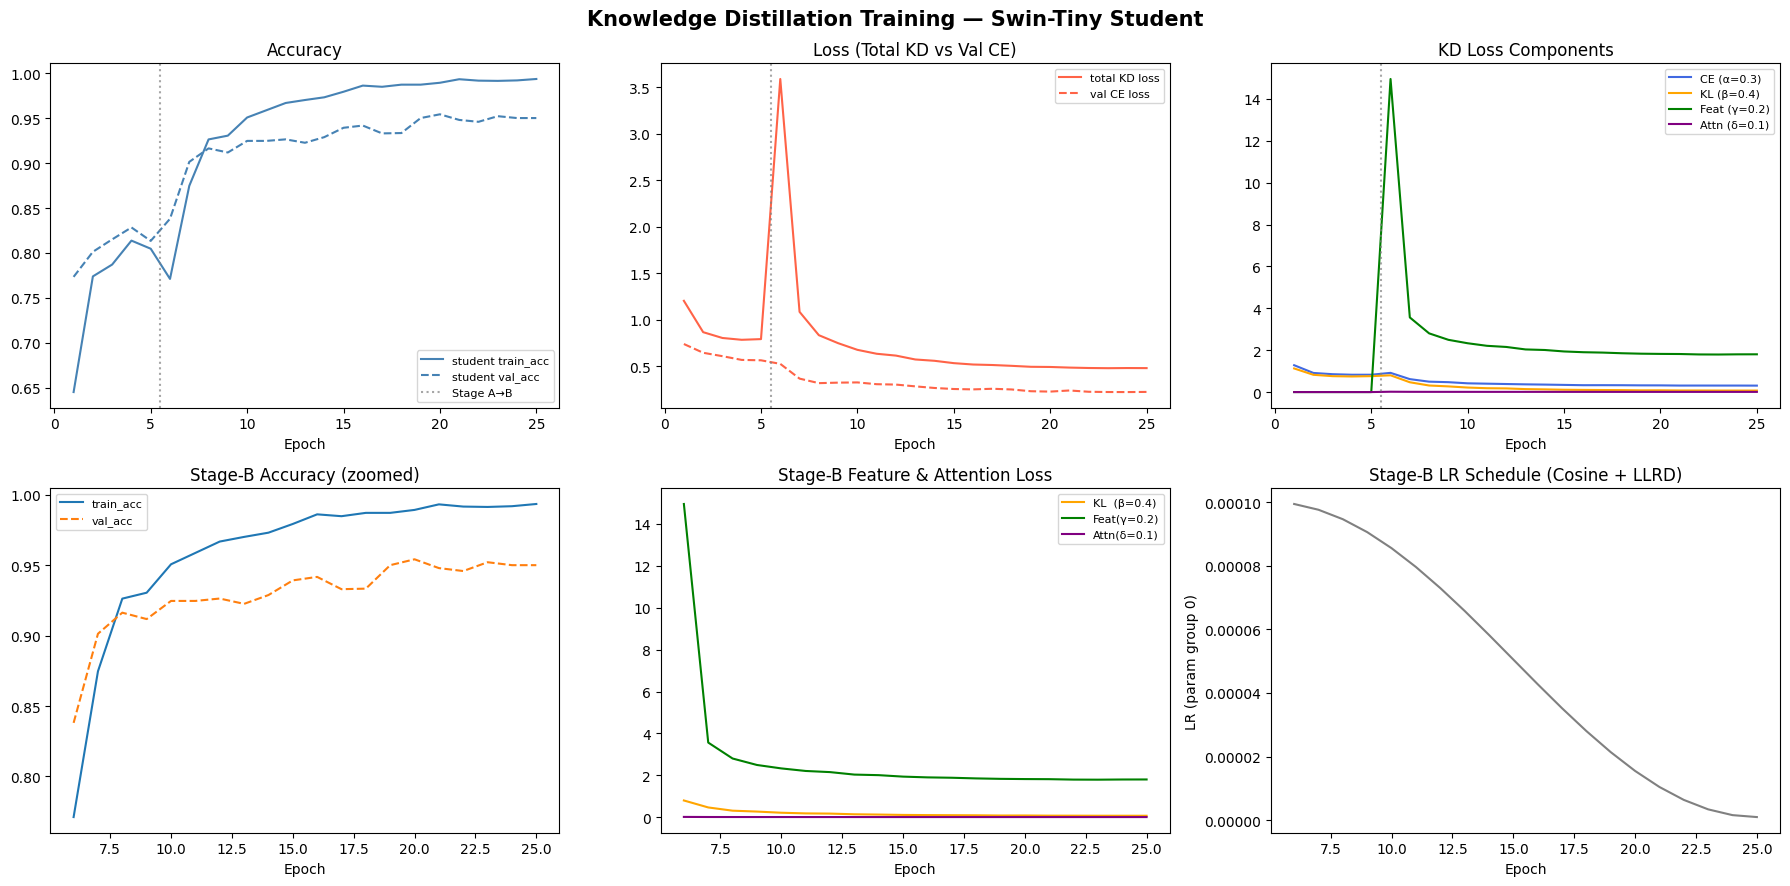

In [31]:
history_kd_all = pd.concat([history_kd_a, history_kd_b], ignore_index=True)
stage_switch   = KD_EPOCHS_A + 0.5   # vertical line position

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle('Knowledge Distillation Training — Swin-Tiny Student', fontsize=15, fontweight='bold')

# ── Accuracy ────────────────────────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(history_kd_all['epoch'], history_kd_all['train_acc'], label='student train_acc', color='steelblue')
ax.plot(history_kd_all['epoch'], history_kd_all['val_acc'],   label='student val_acc',   color='steelblue', linestyle='--')
ax.axvline(stage_switch, color='gray', linestyle=':', alpha=0.7, label='Stage A→B')
ax.set_title('Accuracy')
ax.set_xlabel('Epoch')
ax.legend(fontsize=8)

# ── Total KD Loss ────────────────────────────────────────────────────────────
ax = axes[0, 1]
ax.plot(history_kd_all['epoch'], history_kd_all['loss_total'], label='total KD loss', color='tomato')
ax.plot(history_kd_all['epoch'], history_kd_all['val_loss'],   label='val CE loss',   color='tomato', linestyle='--')
ax.axvline(stage_switch, color='gray', linestyle=':', alpha=0.7)
ax.set_title('Loss (Total KD vs Val CE)')
ax.set_xlabel('Epoch')
ax.legend(fontsize=8)

# ── Loss Components ───────────────────────────────────────────────────────────
ax = axes[0, 2]
ax.plot(history_kd_all['epoch'], history_kd_all['loss_ce'],   label=f'CE (α={KD_ALPHA})',    color='royalblue')
ax.plot(history_kd_all['epoch'], history_kd_all['loss_kl'],   label=f'KL (β={KD_BETA})',     color='orange')
ax.plot(history_kd_all['epoch'], history_kd_all['loss_feat'], label=f'Feat (γ={KD_GAMMA})',  color='green')
ax.plot(history_kd_all['epoch'], history_kd_all['loss_attn'], label=f'Attn (δ={KD_DELTA})',  color='purple')
ax.axvline(stage_switch, color='gray', linestyle=':', alpha=0.7)
ax.set_title('KD Loss Components')
ax.set_xlabel('Epoch')
ax.legend(fontsize=8)

# ── Stage-B only zoomed ───────────────────────────────────────────────────────
stage_b = history_kd_all[history_kd_all['stage'] == 'B']

ax = axes[1, 0]
ax.plot(stage_b['epoch'], stage_b['train_acc'], label='train_acc')
ax.plot(stage_b['epoch'], stage_b['val_acc'],   label='val_acc', linestyle='--')
ax.set_title('Stage-B Accuracy (zoomed)')
ax.set_xlabel('Epoch')
ax.legend(fontsize=8)

ax = axes[1, 1]
ax.plot(stage_b['epoch'], stage_b['loss_kl'],   label=f'KL  (β={KD_BETA})', color='orange')
ax.plot(stage_b['epoch'], stage_b['loss_feat'], label=f'Feat(γ={KD_GAMMA})', color='green')
ax.plot(stage_b['epoch'], stage_b['loss_attn'], label=f'Attn(δ={KD_DELTA})', color='purple')
ax.set_title('Stage-B Feature & Attention Loss')
ax.set_xlabel('Epoch')
ax.legend(fontsize=8)

ax = axes[1, 2]
ax.plot(stage_b['epoch'], stage_b['lr'], color='gray')
ax.set_title('Stage-B LR Schedule (Cosine + LLRD)')
ax.set_xlabel('Epoch')
ax.set_ylabel('LR (param group 0)')

plt.tight_layout()
plt.show()


<div style="background: linear-gradient(90deg, #1a237e 0%, #283593 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700;">🔍 KD-11. Student Test Set Evaluation</h2>
</div>

=== Student (Swin-Tiny) Test Evaluation ===


predicting:   0%|          | 0/15 [00:00<?, ?it/s]

Student Test Accuracy : 0.9349
Teacher Test Accuracy : 0.9622
Accuracy gap          : 0.0273

Classification Report (Student):
                     precision    recall  f1-score   support

          Cardboard     0.9318    0.8913    0.9111        46
      Food Organics     0.9524    0.9756    0.9639        41
              Glass     0.9750    0.9286    0.9512        42
              Metal     0.8941    0.9620    0.9268        79
Miscellaneous Trash     0.9375    0.9000    0.9184        50
              Paper     0.9608    0.9800    0.9703        50
            Plastic     0.9222    0.8925    0.9071        93
      Textile Trash     0.9375    0.9375    0.9375        32
         Vegetation     0.9545    0.9767    0.9655        43

           accuracy                         0.9349       476
          macro avg     0.9407    0.9382    0.9391       476
       weighted avg     0.9353    0.9349    0.9347       476



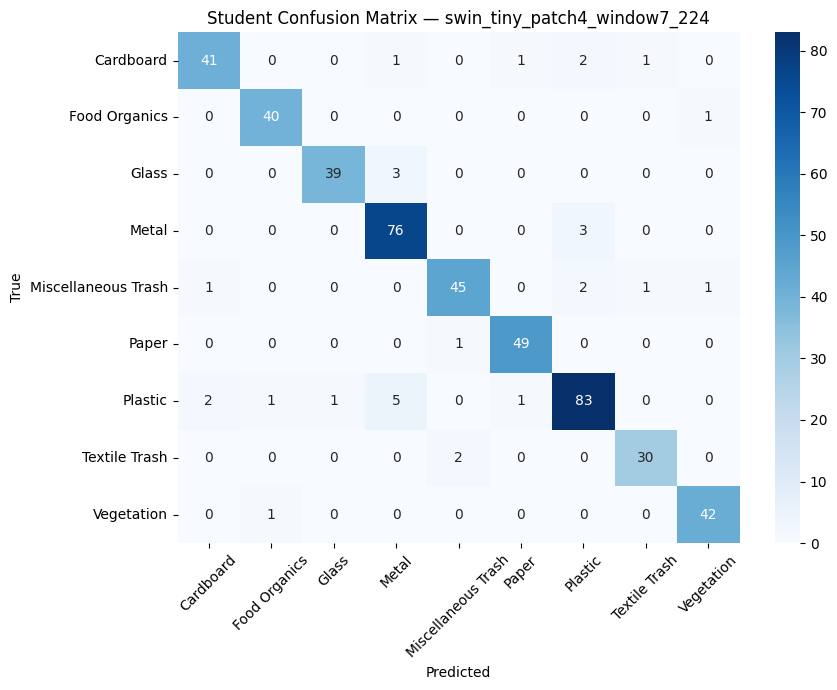

In [32]:
print("=== Student (Swin-Tiny) Test Evaluation ===")
y_true_s, y_pred_s = predict_loader(student, test_loader)

student_acc = (y_true_s == y_pred_s).mean()
print(f'Student Test Accuracy : {student_acc:.4f}')
print(f'Teacher Test Accuracy : {test_acc:.4f}')
print(f'Accuracy gap          : {test_acc - student_acc:.4f}')

print('\nClassification Report (Student):')
print(classification_report(y_true_s, y_pred_s, target_names=class_names, digits=4))

cm_s = confusion_matrix(y_true_s, y_pred_s)
plt.figure(figsize=(9, 7))
sns.heatmap(
    cm_s, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names
)
plt.title(f'Student Confusion Matrix — {STUDENT_BACKBONE}')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


<div style="background: linear-gradient(90deg, #1a237e 0%, #283593 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700;">📊 KD-12. Teacher vs Student — Full Comparison</h2>
</div>

=== Per-Class F1: Teacher vs Student ===
              class  teacher_f1  student_f1  f1_gap
              Metal      0.9811      0.9268  0.0543
          Cardboard      0.9556      0.9111  0.0444
Miscellaneous Trash      0.9592      0.9184  0.0408
              Glass      0.9882      0.9512  0.0370
         Vegetation      0.9885      0.9655  0.0230
            Plastic      0.9297      0.9071  0.0226
      Textile Trash      0.9524      0.9375  0.0149
      Food Organics      0.9639      0.9639  0.0000
              Paper      0.9608      0.9703 -0.0095


/tmp/ipykernel_55/3333824559.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(compare_df['class'], rotation=45, ha='right')


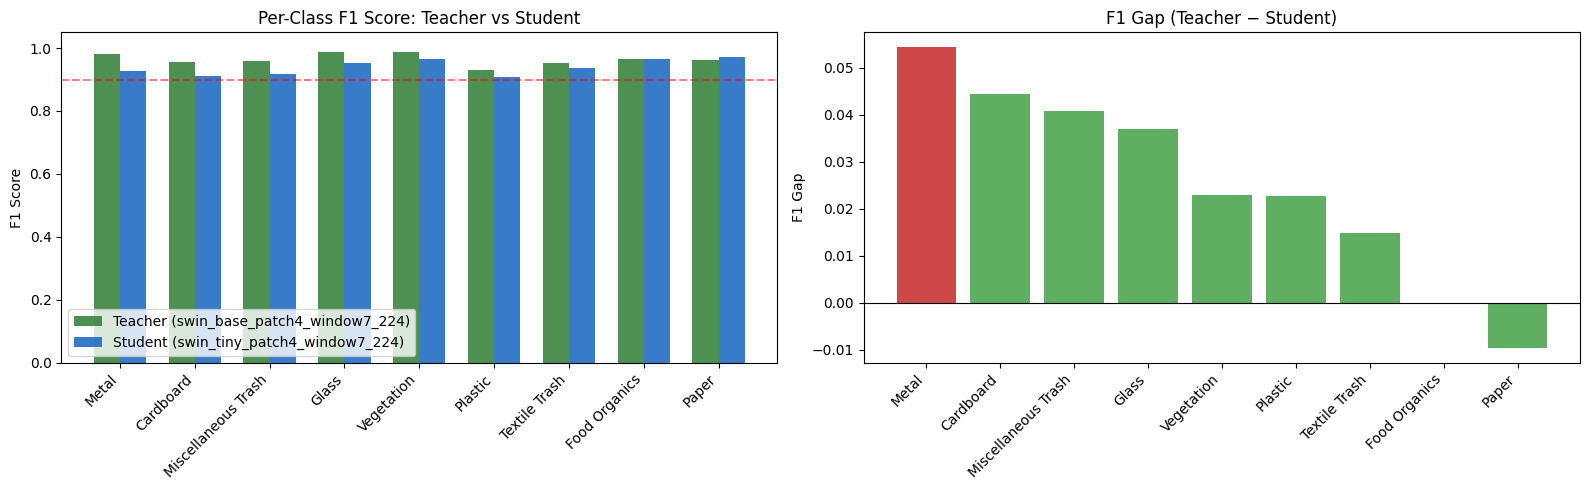


=== Summary Comparison ===
Metric                         Teacher      Student        Gap
--------------------------------------------------------------
Accuracy                        0.9622       0.9349    +0.0273
Macro Precision                 0.9647       0.9407    +0.0241
Macro Recall                    0.9644       0.9382    +0.0262
Macro F1                        0.9644       0.9391    +0.0253
Params (M)                     86.7524      27.5263   +59.2262


In [33]:
# ── Per-class F1 comparison ──────────────────────────────────────────────────
_, _, f1_t, _ = precision_recall_fscore_support(y_true,   y_pred,   labels=list(range(len(class_names))), zero_division=0)
_, _, f1_s, _ = precision_recall_fscore_support(y_true_s, y_pred_s, labels=list(range(len(class_names))), zero_division=0)

compare_df = pd.DataFrame({
    'class':       class_names,
    'teacher_f1':  f1_t,
    'student_f1':  f1_s,
    'f1_gap':      f1_t - f1_s,
})
compare_df = compare_df.sort_values('f1_gap', ascending=False)

print("=== Per-Class F1: Teacher vs Student ===")
print(compare_df.to_string(index=False, float_format='{:.4f}'.format))

# ── Bar chart ────────────────────────────────────────────────────────────────
x = np.arange(len(class_names))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
bars_t = ax.bar(x - width/2, compare_df['teacher_f1'], width, label=f'Teacher ({BACKBONE})',     color='#2e7d32', alpha=0.85)
bars_s = ax.bar(x + width/2, compare_df['student_f1'], width, label=f'Student ({STUDENT_BACKBONE})', color='#1565c0', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(compare_df['class'], rotation=45, ha='right')
ax.set_ylim(0, 1.05)
ax.set_title('Per-Class F1 Score: Teacher vs Student')
ax.set_ylabel('F1 Score')
ax.legend()
ax.axhline(y=0.90, color='red', linestyle='--', alpha=0.5, label='0.90 threshold')

ax = axes[1]
colors = ['#c62828' if g > 0.05 else '#43a047' for g in compare_df['f1_gap']]
ax.bar(compare_df['class'], compare_df['f1_gap'], color=colors, alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticklabels(compare_df['class'], rotation=45, ha='right')
ax.set_xticks(range(len(compare_df)))
ax.set_title('F1 Gap (Teacher − Student)')
ax.set_ylabel('F1 Gap')

plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n=== Summary Comparison ===")
print(f"{'Metric':<25} {'Teacher':>12} {'Student':>12} {'Gap':>10}")
print("-" * 62)

t_prec, t_rec, t_f1, _ = precision_recall_fscore_support(y_true,   y_pred,   average='macro', zero_division=0)
s_prec, s_rec, s_f1, _ = precision_recall_fscore_support(y_true_s, y_pred_s, average='macro', zero_division=0)

rows = [
    ('Accuracy',          test_acc,       student_acc),
    ('Macro Precision',   t_prec,         s_prec),
    ('Macro Recall',      t_rec,          s_rec),
    ('Macro F1',          t_f1,           s_f1),
    ('Params (M)',        teacher_params/1e6, s_params/1e6),
]
for name, t_val, s_val in rows:
    gap = t_val - s_val
    print(f"{name:<25} {t_val:>12.4f} {s_val:>12.4f} {gap:>+10.4f}")


<div style="background: linear-gradient(90deg, #1a237e 0%, #283593 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700;">⚡ KD-13. Inference Speed Benchmark</h2>
</div>

Real-world speedup depends on hardware and batch size. We benchmark both models with the same  
batch of 32 images, warming up first to get stable GPU timings.


In [34]:
import time

def benchmark_model(model, loader, n_batches=20, label=''):
    model.eval()
    images, _ = next(iter(loader))
    images = images.to(device)

    # Warm-up
    with torch.no_grad():
        for _ in range(3):
            _ = model(images)
    if device.type == 'cuda':
        torch.cuda.synchronize()

    # Timed runs
    start = time.perf_counter()
    with torch.no_grad():
        for i, (imgs, _) in enumerate(loader):
            if i >= n_batches:
                break
            imgs = imgs.to(device)
            _ = model(imgs)
            if device.type == 'cuda':
                torch.cuda.synchronize()
    elapsed = time.perf_counter() - start

    total_images = min(n_batches, len(loader)) * BATCH_SIZE
    fps = total_images / elapsed
    ms_per_img = elapsed / total_images * 1000
    print(f"{label:<35}: {fps:>7.1f} img/s  |  {ms_per_img:>5.2f} ms/img  |  {elapsed:.2f}s total")
    return fps, ms_per_img

print(f"Benchmarking over {20} batches × {BATCH_SIZE} images on {device}...")
print()
t_fps, t_ms = benchmark_model(teacher, test_loader, label=f'Teacher ({BACKBONE})')
s_fps, s_ms = benchmark_model(student, test_loader, label=f'Student ({STUDENT_BACKBONE})')

print(f"\nSpeedup  : {s_fps/t_fps:.2f}×  faster")
print(f"Latency  : {t_ms:.2f} ms → {s_ms:.2f} ms  ({(1 - s_ms/t_ms)*100:.1f}% reduction)")


Benchmarking over 20 batches × 32 images on cuda...

Teacher (swin_base_patch4_window7_224):    73.3 img/s  |  13.65 ms/img  |  6.55s total
Student (swin_tiny_patch4_window7_224):   175.1 img/s  |   5.71 ms/img  |  2.74s total

Speedup  : 2.39×  faster
Latency  : 13.65 ms → 5.71 ms  (58.2% reduction)


<div style="background: linear-gradient(90deg, #1a237e 0%, #283593 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700;">💾 KD-14. Save Student Artifacts</h2>
</div>

In [35]:
kd_dir = Path('./artifacts/kd')
kd_dir.mkdir(parents=True, exist_ok=True)

student_path  = kd_dir / f'{STUDENT_BACKBONE}_kd_realwaste_best.pt'
adapter_path  = kd_dir / 'feature_adapter.pt'
kd_meta_path  = kd_dir / 'kd_metadata.json'

# ── Save student checkpoint ─────────────────────────────────────────────────
torch.save({
    'model_state_dict':   student.state_dict(),
    'backbone':           STUDENT_BACKBONE,
    'class_names':        class_names,
    'img_size':           IMG_SIZE,
    'mean':               IMAGENET_MEAN,
    'std':                IMAGENET_STD,
}, student_path)

# ── Save adapter (useful for feature-level retrieval / debugging) ────────────
torch.save(feature_adapter.state_dict(), adapter_path)

# ── Save metadata ────────────────────────────────────────────────────────────
with open(kd_meta_path, 'w') as f:
    json.dump({
        'teacher_backbone':     BACKBONE,
        'student_backbone':     STUDENT_BACKBONE,
        'teacher_params_M':     round(teacher_params / 1e6, 2),
        'student_params_M':     round(s_params / 1e6, 2),
        'compression_ratio':    round(teacher_params / s_params, 2),
        'kd_temperature':       KD_TEMPERATURE,
        'kd_alpha':             KD_ALPHA,
        'kd_beta':              KD_BETA,
        'kd_gamma':             KD_GAMMA,
        'kd_delta':             KD_DELTA,
        'teacher_test_acc':     round(float(test_acc), 4),
        'student_test_acc':     round(float(student_acc), 4),
        'accuracy_gap':         round(float(test_acc - student_acc), 4),
        'teacher_f1_macro':     round(float(t_f1), 4),
        'student_f1_macro':     round(float(s_f1), 4),
        'class_names':          class_names,
        'img_size':             IMG_SIZE,
        'mean':                 IMAGENET_MEAN,
        'std':                  IMAGENET_STD,
    }, f, indent=2)

print("Saved student checkpoint :", student_path)
print("Saved feature adapter    :", adapter_path)
print("Saved KD metadata        :", kd_meta_path)
print()
print("=== Final Summary ===")
print(f"Teacher : {BACKBONE:<45} {teacher_params/1e6:.1f} M | acc {test_acc:.4f} | macro-F1 {t_f1:.4f}")
print(f"Student : {STUDENT_BACKBONE:<45} {s_params/1e6:.1f} M | acc {student_acc:.4f} | macro-F1 {s_f1:.4f}")
print(f"Compression : {teacher_params/s_params:.1f}×  |  Acc gap : {test_acc-student_acc:+.4f}")


Saved student checkpoint : artifacts/kd/swin_tiny_patch4_window7_224_kd_realwaste_best.pt
Saved feature adapter    : artifacts/kd/feature_adapter.pt
Saved KD metadata        : artifacts/kd/kd_metadata.json

=== Final Summary ===
Teacher : swin_base_patch4_window7_224                  86.8 M | acc 0.9622 | macro-F1 0.9644
Student : swin_tiny_patch4_window7_224                  27.5 M | acc 0.9349 | macro-F1 0.9391
Compression : 3.2×  |  Acc gap : +0.0273
